In [23]:
import numpy as np 
# lam is the regularization parameter , we used L2 Regularization to prevent overfitting
def gradient(x,y,w,b,lam=0.1):
    m = x.shape[0] # number of examples
    n = x.shape[1] # number of features
    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        pred = b
        for j in range(n):
            pred += w[j] * x[i][j]
        error = pred - y[i]
        dj_db += error
        for j in range(n):
            dj_dw[j] += error * x[i][j]
    # lam is the regularization parameter
    for j in range(n):
        dj_dw[j] += lam*w[j] 
        dj_dw[j] /= m
    dj_db /= m
    return dj_dw, dj_db
def cost(x,y,w,b,lam=0.1):
    m = x.shape[0] 
    n = x.shape[1]
    J = 0
    for i in range(m):
        pred = np.dot(w,x[i])+b
        J += (pred - y[i])**2
    for j in range(n):
        J += lam*w[j]**2
    return J/(2*m)
# alpha : learning_rate 
def linear_regression(x,y,n_iter,alpha,lam):
    m = x.shape[0] 
    n = x.shape[1] 
    # initialize w,b
    w = np.full(n,0.5)
    b = 1
    J_history = []
    temp_w = np.zeros(n)
    # use forloop to control the number of iteration in the gradient descent 
    for j in range(n_iter):
        dj_dw, dj_db = gradient(x,y,w,b,lam)
        for i in range(n):
            temp_w[i] = w[i] - alpha*dj_dw[i]
            w[i] = temp_w[i]
        temp_b = b - alpha*dj_db
        b = temp_b
        J_history.append(cost(x,y,w,b,lam))
    return w,b,J_history
def predictions(x,w,b):
    m = x.shape[0] 
    pred = np.zeros(m)
    for i in range(m):
        pred[i] = np.dot(w,x[i])+b
    return pred


In [24]:
import pandas as pd
df = pd.read_csv("multiple_linear_regression_dataset.csv")
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [25]:
x = df.drop(["income"],axis=1)
y = df["income"]

In [26]:
x = x.to_numpy()
x_scaled = (x - np.mean(x,axis=0))/np.std(x,axis=0)
y = y.to_numpy()
w,b,J_hist = linear_regression(x_scaled,y,1000,0.01,0.01)
pred_train = predictions(x_scaled, w, b)

In [27]:
mse_train = np.mean((pred_train - y)**2)
print(f"Training result: w = {w}, b = {b}")
print(f"Train MSE: {mse_train}")

Training result: w = [-862.87395023 8583.72319845], b = 40733.74144082235
Train MSE: 1542592.3154493324


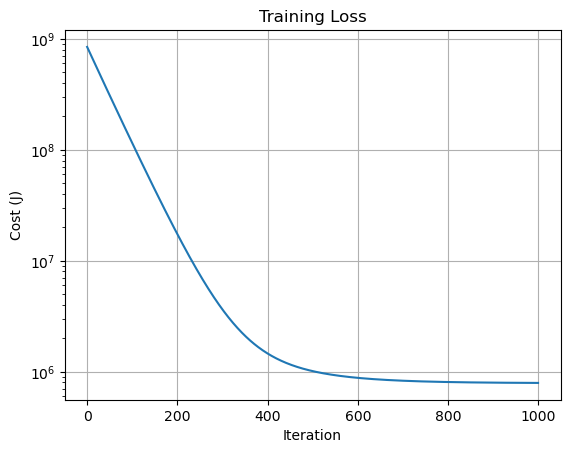

In [28]:
import matplotlib.pyplot as plt

# Training loss plot
plt.plot(range(len(J_hist)), J_hist)
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Training Loss')
plt.yscale('log')  
plt.grid(True)
plt.show()

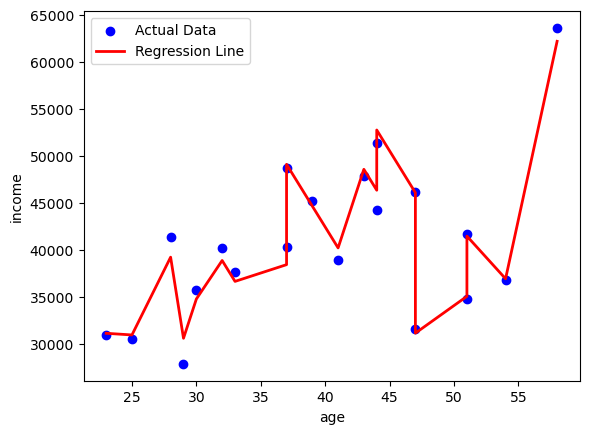

In [29]:
# ordering the x values ascending and reordering the matching prediction so each x is paired with the correct y
age = df['age'].values
order = np.argsort(age)
plt.scatter(age, y, color="blue", label="Actual Data")
plt.plot(age[order], pred_train[order], color="red", linewidth=2, label="Regression Line")
plt.xlabel('age')
plt.ylabel('income')
plt.legend()
plt.show()

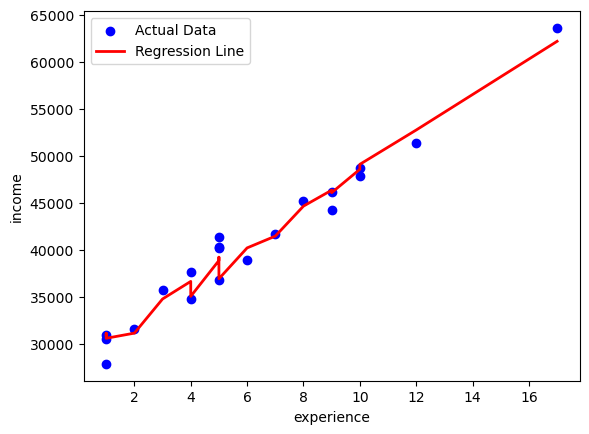

In [30]:
experience = df["experience"].values
order = np.argsort(experience)
plt.scatter(experience, y, color="blue", label="Actual Data")
plt.plot(experience[order], pred_train[order], color="red", linewidth=2, label="Regression Line")
plt.xlabel('experience')
plt.ylabel('income')
plt.legend()
plt.show()